Saving chd.csv to chd (5).csv


,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     100 non-null    int64
 1   chd     100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB
Shape of X_train: (70, 1)
Shape of y_train: (70,)
Shape of X_test: (30, 1)
Shape of y_test: (30,)
Intercept: [-5.6511192] 
Coefficients: [[0.11144141]]
Predicted probability for class '0' and '1' respectively: [[0.91828861 0.08171139]]

Predicted target i.e. 'chd' value: [0]
Accuracy score of the model on training data: 0.7428571428571429
Accuracy score of the model on test data: 0.7333333333333333


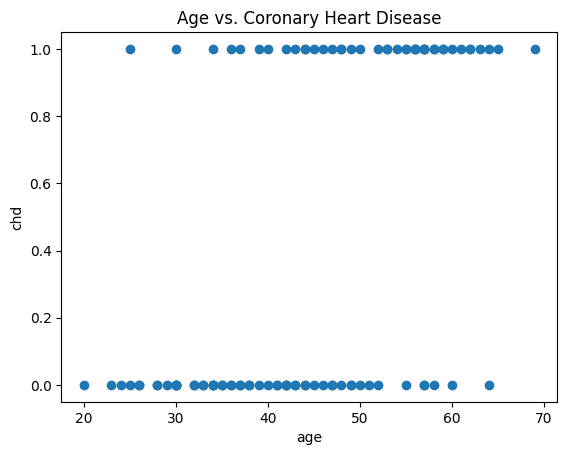

In [6]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline

uploaded = files.upload()
chd_filename = next(iter(uploaded))

df = pd.read_csv(io.StringIO(uploaded[chd_filename].decode('utf-8')))
display(df.head())
df.info()

import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter("age","chd",data=df)
plt.xlabel("age")
plt.ylabel("chd")
plt.title("Age vs. Coronary Heart Disease")

from sklearn.model_selection import train_test_split
predictors = ["age"]
target = "chd"
X = df[predictors]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
print("Intercept:",model.intercept_,"\nCoefficients:", model.coef_)

# Convert the numpy array to a DataFrame with the correct feature name
test_df = pd.DataFrame(np.array([29]).reshape(1,-1), columns=predictors)
print("Predicted probability for class '0' and '1' respectively:", model.predict_proba(test_df))
print("\nPredicted target i.e. 'chd' value:",model.predict(test_df))
print("Accuracy score of the model on training data:", model.score(X_train, y_train))
print("Accuracy score of the model on test data:", model.score(X_test, y_test))
